<a href="https://colab.research.google.com/github/FayezaQareen-TW/PRODIGY_DS_04/blob/main/PRODIGY_DS_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install textblob
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

Shape: (74682, 4)
   target           id    entity  \
0    2401  Borderlands  Positive   
1    2401  Borderlands  Positive   
2    2401  Borderlands  Positive   
3    2401  Borderlands  Positive   
4    2401  Borderlands  Positive   

                                                text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  

Sentiment Distribution:
target
9200    6
2401    6
2402    6
2403    6
2404    6
       ..
2420    6
2419    6
2418    6
2417    6
2416    6
Name: count, Length: 12447, dtype: int64

Cleaning done!

Sentiment Results:
sentiment
Positive    2286
Negative    1422
Neutral     1292
Name: count, dtype: int64


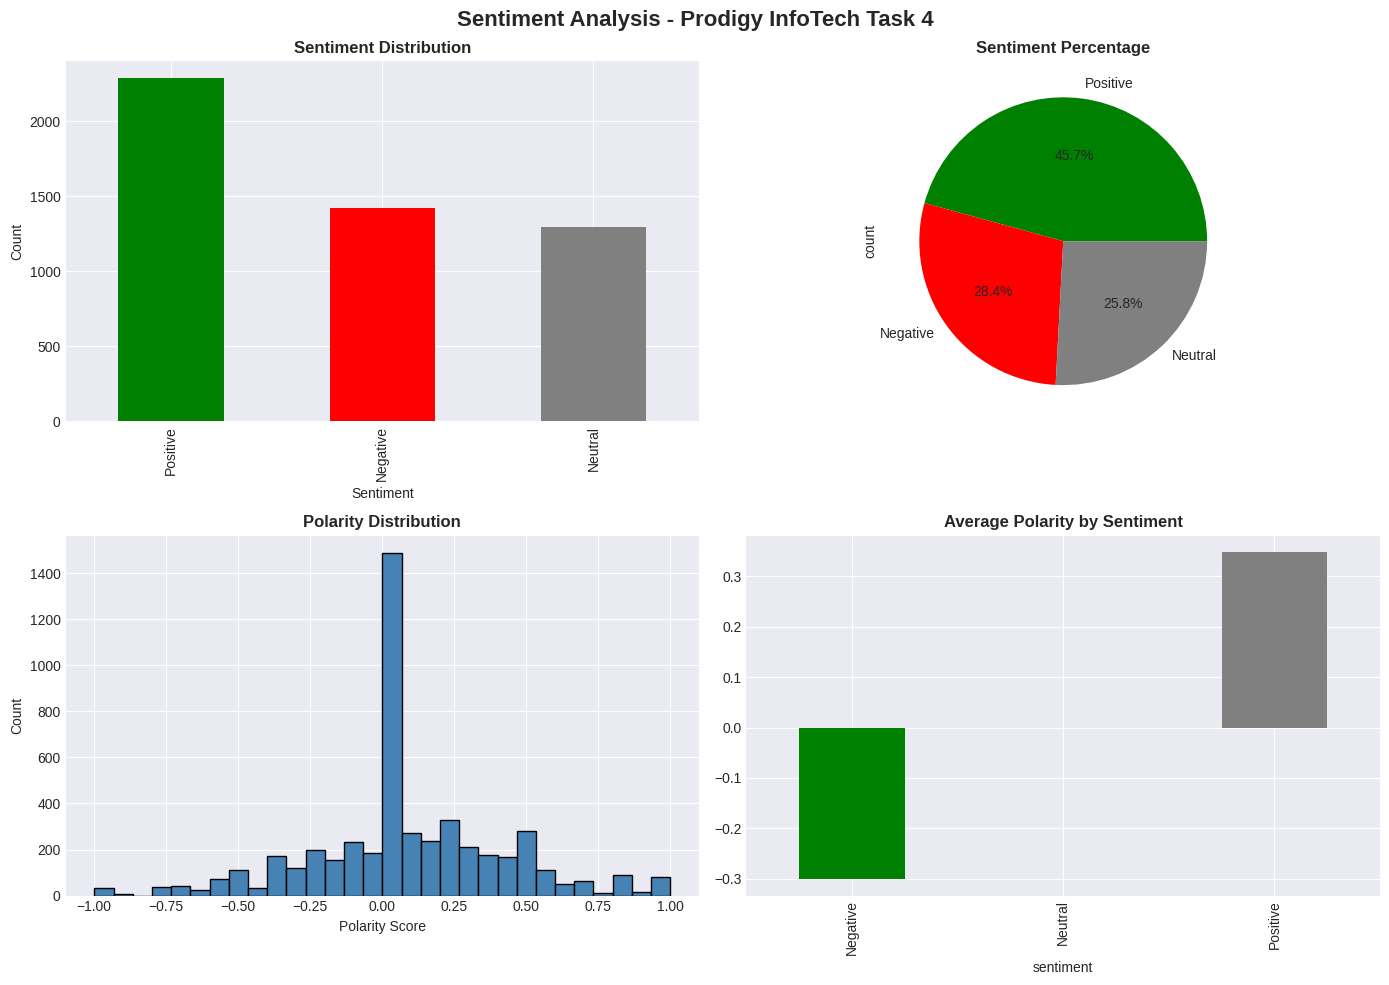

Task 4 Complete! ✅


In [4]:
# PRODIGY INFOTECH - TASK 04
# Sentiment Analysis on Social Media Data
# Name: [Your Name]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

# STEP 1 - Load Data
df = pd.read_csv('twitter_training.csv',
                  encoding='latin-1',
                  header=None)

# Rename columns
df.columns = ['target', 'id', 'entity', 'text']

print("Shape:", df.shape)
print(df.head())
print("\nSentiment Distribution:")
print(df['target'].value_counts())

# STEP 2 - Clean Data
import re

def clean_text(text):
    # Remove links
    text = re.sub(r'http\S+', '', text)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower().strip()
    return text

df['clean_text'] = df['text'].astype(str).apply(clean_text)
print("\nCleaning done!")

# STEP 3 - Sentiment Analysis
def get_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

# Use sample for speed
df_sample = df.sample(n=5000, random_state=42)
df_sample['sentiment'] = df_sample['clean_text'].apply(get_sentiment)
df_sample['polarity'] = df_sample['clean_text'].apply(get_polarity)

print("\nSentiment Results:")
print(df_sample['sentiment'].value_counts())

# STEP 4 - Visualizations
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Chart 1 - Sentiment Distribution
colors = ['green', 'red', 'gray']
df_sample['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0,0],
    color=colors)
axes[0,0].set_title('Sentiment Distribution',
                     fontweight='bold')
axes[0,0].set_xlabel('Sentiment')
axes[0,0].set_ylabel('Count')

# Chart 2 - Sentiment Pie Chart
df_sample['sentiment'].value_counts().plot(
    kind='pie', ax=axes[0,1],
    colors=colors,
    autopct='%1.1f%%')
axes[0,1].set_title('Sentiment Percentage',
                     fontweight='bold')

# Chart 3 - Polarity Distribution
axes[1,0].hist(df_sample['polarity'],
               bins=30,
               color='steelblue',
               edgecolor='black')
axes[1,0].set_title('Polarity Distribution',
                     fontweight='bold')
axes[1,0].set_xlabel('Polarity Score')
axes[1,0].set_ylabel('Count')

# Chart 4 - Average polarity
avg_polarity = df_sample.groupby(
    'sentiment')['polarity'].mean()
avg_polarity.plot(kind='bar',
                  ax=axes[1,1],
                  color=colors)
axes[1,1].set_title('Average Polarity by Sentiment',
                     fontweight='bold')

plt.suptitle('Sentiment Analysis - Prodigy InfoTech Task 4',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=300)
plt.show()

print("Task 4 Complete! ✅")